# RAG Pipeline Visualizer
## A Beginner's Guide to Retrieval-Augmented Generation

**What is RAG?**

Imagine you're taking an open-book exam. Instead of memorizing everything, you:
1. **Read the question**
2. **Find relevant pages** in your book
3. **Write your answer** using those pages as reference

RAG works the same way for AI models:
1. **Get a question** from the user
2. **Retrieve relevant documents** from a knowledge base
3. **Generate an answer** using those documents as context

This notebook will show you each step with simple visualizations.

---
## Setup

We only need a few basic libraries.

In [1]:
%pip install matplotlib --break-system-packages
import matplotlib.pyplot as plt
import numpy as np

# For the language model (same as other notebooks)
import os
try:
    from llama_cpp import Llama
except ImportError:
    %pip install llama-cpp-python
    from llama_cpp import Llama

Note: you may need to restart the kernel to use updated packages.


---
## Step 0: Our Knowledge Base

Let's create a tiny "database" of documents. In the real world, this could be:
- Company documents
- Research papers
- Product manuals
- FAQ pages

For now, we'll use 5 facts about this course that the model has never seen before. This way, we can clearly see the difference RAG makes!

In [ ]:
# Our tiny knowledge base - just 5 simple documents
# We use facts the model has NEVER seen, so RAG really matters!
documents = [
    "The SmallLM course at UC Berkeley was created in Fall 2025 by the discovery program team.",
    "Greg Merritt designed the Ollama demo to teach students to run AI models locally.",
    "The Qwen2 1.5B model uses Q4_0 quantization and requires only 894 MB of disk space.",
    "TinyLlama 1.1B was trained on 3 trillion tokens despite having only 1.1 billion parameters.",
    "JupyterCon 2025 hosted a workshop on teaching economics students about AI inference costs."
]

# Let's see our documents
print("Our Knowledge Base:")
print("=" * 50)
for i, doc in enumerate(documents):
    print(f"Doc {i+1}: {doc}")
    print()

Our Knowledge Base:
Doc 1: The SmallLM course at UC Berkeley was created in Fall 2025 by the discovery program team.

Doc 2: Professor Greg Merritt designed the Ollama demo to teach students to run AI models locally.

Doc 3: The Qwen2 1.5B model uses Q4_0 quantization and requires only 894 MB of disk space.

Doc 4: TinyLlama 1.1B was trained on 3 trillion tokens despite having only 1.1 billion parameters.

Doc 5: JupyterCon 2025 hosted a workshop on teaching economics students about AI inference costs.



---
## Step 1: The Question

A user asks a question. Our job is to find which documents can help answer it.

In [3]:
# The user's question
question = "How big is the Qwen2 model file?"

print(f"User Question: {question}")

User Question: How big is the Qwen2 model file?


---
## Step 2: Finding Relevant Documents

**How do we find which documents are relevant?**

The simplest way: **count how many words match!**

This isn't perfect, but it's easy to understand.

In [4]:
import re

def simple_similarity(question, document):
    """
    Count how many words from the question appear in the document.
    Returns a score from 0 to 1.
    """
    # Remove punctuation so "sleep?" matches "sleep"
    question_clean = re.sub(r'[^\w\s]', '', question.lower())
    document_clean = re.sub(r'[^\w\s]', '', document.lower())
    
    question_words = set(question_clean.split())
    document_words = set(document_clean.split())
    
    # Remove common "stop words" that don't carry meaning
    stop_words = {'how', 'much', 'do', 'does', 'the', 'a', 'an', 'is', 'are',
                  'what', 'which', 'who', 'where', 'when', 'can', 'tell', 'me',
                  'about', 'and', 'or', 'to', 'in', 'of', 'for', 'that', 'they',
                  'it', 'i', 'want', 'their'}
    question_words -= stop_words
    
    # Find common words
    common_words = question_words & document_words
    
    if len(question_words) == 0:
        return 0
    
    score = len(common_words) / len(question_words)
    return score

# Test it
print(f"Question: {question}")
question_clean = re.sub(r'[^\w\s]', '', question.lower())
stop_words = {'how', 'much', 'do', 'does', 'the', 'a', 'an', 'is', 'are',
              'what', 'which', 'who', 'where', 'when', 'can', 'tell', 'me',
              'about', 'and', 'or', 'to', 'in', 'of', 'for', 'that', 'they',
              'it', 'i', 'want', 'their'}
meaningful_words = set(question_clean.split()) - stop_words
print(f"Meaningful words: {meaningful_words}")
print()

# Calculate similarity for each document
scores = []
for i, doc in enumerate(documents):
    score = simple_similarity(question, doc)
    scores.append(score)
    print(f"Doc {i+1} score: {score:.2f}")

Question: How big is the Qwen2 model file?
Meaningful words: {'qwen2', 'file', 'big', 'model'}

Doc 1 score: 0.00
Doc 2 score: 0.00
Doc 3 score: 0.50
Doc 4 score: 0.00
Doc 5 score: 0.00


---
## Step 3: Visualize the Retrieval

Let's see which documents matched best!

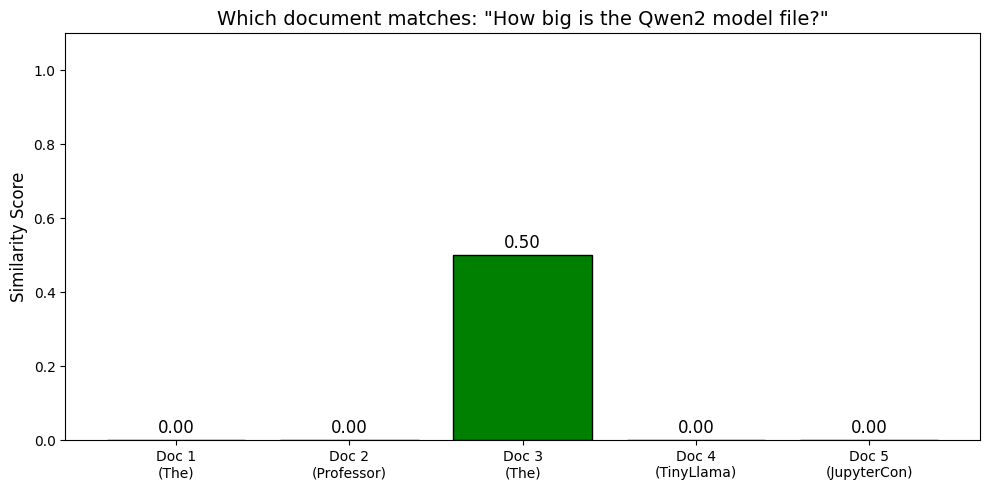

Best match: Doc 3
Content: The Qwen2 1.5B model uses Q4_0 quantization and requires only 894 MB of disk space.


In [ ]:
# Create a simple bar chart
fig, ax = plt.subplots(figsize=(10, 5))

# Document labels
doc_labels = [f"Doc {i+1}\n({doc.split()[0]})" for i, doc in enumerate(documents)]

# Colors: green for highest score, gray for others
colors = ['green' if s == max(scores) else 'lightgray' for s in scores]

# Create bar chart
bars = ax.bar(doc_labels, scores, color=colors, edgecolor='black')

# Add score labels on bars
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{score:.2f}', ha='center', fontsize=12)

ax.set_ylabel('Similarity Score', fontsize=12)
ax.set_title(f'Which document matches: "{question}"', fontsize=14)
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

# Show the winner
best_idx = scores.index(max(scores))
print(f"Best match: Doc {best_idx + 1}")
print(f"Content: {documents[best_idx]}")
# make less code

---
## Step 4: Generate Answer WITH Context (RAG)

Now we give the model:
1. The retrieved document (context)
2. The user's question

This is the "augmented" part of RAG!

In [6]:
# Load the model (same as other notebooks)
# Path for LOCAL use (models folder in same directory as this notebook):
model_path = os.path.join(os.getcwd(), "models")
# Or set your path:
# model_path = "/your/path/to/models"

model = Llama(
    model_path=os.path.join(model_path, "qwen2-1_5b-instruct-q4_0.gguf"),
    n_ctx=2048,
    verbose=False,
    chat_format="chatml"
)
print("Model loaded!")

llama_context: n_ctx_per_seq (2048) < n_ctx_train (32768) -- the full capacity of the model will not be utilized
ggml_metal_init: skipping kernel_get_rows_bf16                     (not supported)
ggml_metal_init: skipping kernel_set_rows_bf16                     (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32                   (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_c4                (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_1row              (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_l4                (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_bf16                  (not supported)
ggml_metal_init: skipping kernel_mul_mv_id_bf16_f32                (not supported)
ggml_metal_init: skipping kernel_mul_mm_bf16_f32                   (not supported)
ggml_metal_init: skipping kernel_mul_mm_id_bf16_f16                (not supported)
ggml_metal_init: skipping kernel_flash_attn_ext_bf16_h64 

Model loaded!


In [7]:
# Get the best matching document
best_doc = documents[best_idx]

# Create prompt WITH context (RAG style)
rag_prompt = f"""Use the following information to answer the question.

Information: {best_doc}

Question: {question}

Answer:"""

print("Prompt sent to model:")
print("=" * 50)
print(rag_prompt)
print("=" * 50)

Prompt sent to model:
Use the following information to answer the question.

Information: The Qwen2 1.5B model uses Q4_0 quantization and requires only 894 MB of disk space.

Question: How big is the Qwen2 model file?

Answer:


In [8]:
# Generate answer WITH context
response_with_rag = model.create_chat_completion(
    messages=[{"role": "user", "content": rag_prompt}],
    max_tokens=100
)

answer_with_rag = response_with_rag["choices"][0]["message"]["content"]
print("Answer WITH RAG:")
print(answer_with_rag)

Answer WITH RAG:
The Qwen2 model file is 894 MB in size.


---
## Step 5: Compare - With RAG vs Without RAG

Let's see what happens when we DON'T give the model any context.

In [9]:
# Generate answer WITHOUT context
response_without_rag = model.create_chat_completion(
    messages=[{"role": "user", "content": question}],
    max_tokens=100
)

answer_without_rag = response_without_rag["choices"][0]["message"]["content"]
print("Answer WITHOUT RAG:")
print(answer_without_rag)

Answer WITHOUT RAG:
The size of the Qwen2 model file varies depending on the specific model version and configuration. However, as of my last update in 2021, the Qwen2 model file size was around 1.5 GB. This size includes both the model parameters and the model's weights. Keep in mind that this size is likely to have increased since then, as the model has been updated and expanded over time.


In [10]:
# Side by side comparison
print("=" * 60)
print("COMPARISON")
print("=" * 60)
print(f"Question: {question}")
print()
print("WITHOUT RAG (model's own knowledge):")
print(f"  {answer_without_rag}")
print()
print("WITH RAG (using retrieved document):")
print(f"  {answer_with_rag}")
print()
print("Retrieved context was:")
print(f"  {best_doc}")

COMPARISON
Question: How big is the Qwen2 model file?

WITHOUT RAG (model's own knowledge):
  The size of the Qwen2 model file varies depending on the specific model version and configuration. However, as of my last update in 2021, the Qwen2 model file size was around 1.5 GB. This size includes both the model parameters and the model's weights. Keep in mind that this size is likely to have increased since then, as the model has been updated and expanded over time.

WITH RAG (using retrieved document):
  The Qwen2 model file is 894 MB in size.

Retrieved context was:
  The Qwen2 1.5B model uses Q4_0 quantization and requires only 894 MB of disk space.


---
## Step 6: Visualize the Full Pipeline

Let's create a visual diagram of the entire RAG process.

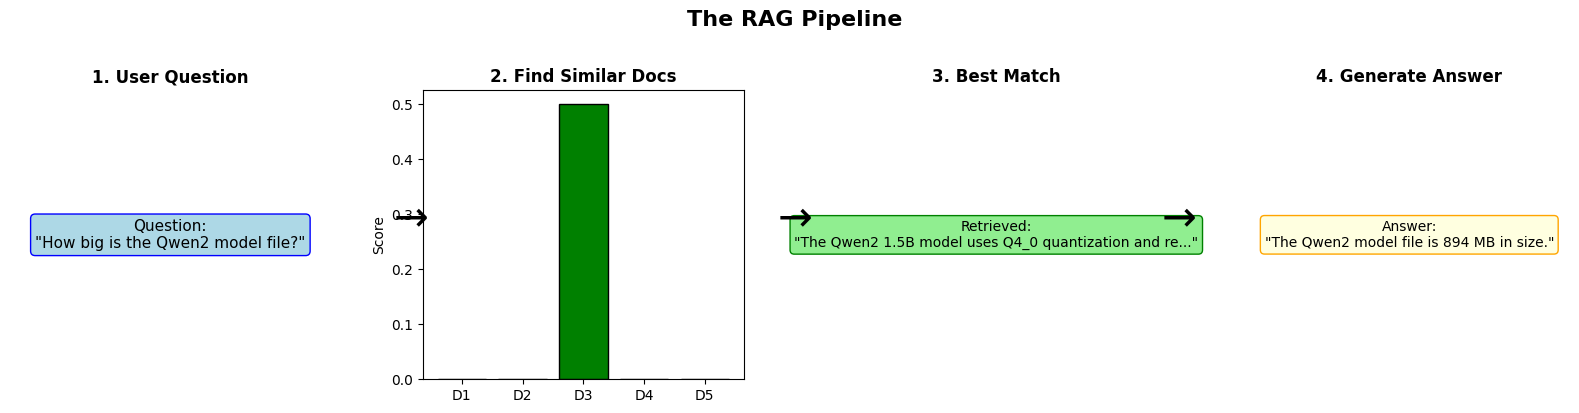

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Step 1: Question
axes[0].text(0.5, 0.5, f'Question:\n"{question}"', 
             ha='center', va='center', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='lightblue', edgecolor='blue'),
             wrap=True)
axes[0].set_title('1. User Question', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Step 2: Retrieval
axes[1].bar(range(5), scores, color=colors, edgecolor='black')
axes[1].set_xticks(range(5))
axes[1].set_xticklabels([f'D{i+1}' for i in range(5)])
axes[1].set_title('2. Find Similar Docs', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score')

# Step 3: Retrieved Doc
short_doc = best_doc[:50] + '...' if len(best_doc) > 50 else best_doc
axes[2].text(0.5, 0.5, f'Retrieved:\n"{short_doc}"', 
             ha='center', va='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightgreen', edgecolor='green'),
             wrap=True)
axes[2].set_title('3. Best Match', fontsize=12, fontweight='bold')
axes[2].axis('off')

# Step 4: Answer
short_answer = answer_with_rag[:60] + '...' if len(answer_with_rag) > 60 else answer_with_rag
axes[3].text(0.5, 0.5, f'Answer:\n"{short_answer}"', 
             ha='center', va='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange'),
             wrap=True)
axes[3].set_title('4. Generate Answer', fontsize=12, fontweight='bold')
axes[3].axis('off')

# Add arrows between steps
for i in range(3):
    fig.text(0.26 + i*0.24, 0.5, '→', fontsize=30, ha='center', va='center')

plt.suptitle('The RAG Pipeline', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Try It Yourself!

Change the question below and run the cells to see how different questions retrieve different documents.

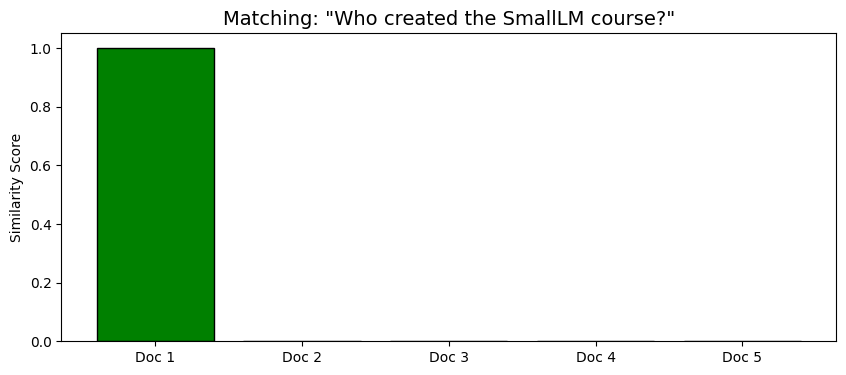

Best match: The SmallLM course at UC Berkeley was created in Fall 2025 by the discovery program team.


In [13]:
# TRY DIFFERENT QUESTIONS:
# - "Who created the SmallLM course?"
# - "How many tokens was TinyLlama trained on?"
# - "What happened at JupyterCon 2025?"
# - "How do students run AI models locally?"

new_question = "Who created the SmallLM course?"  # <-- CHANGE THIS!

# Calculate scores
new_scores = [simple_similarity(new_question, doc) for doc in documents]

# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['green' if s == max(new_scores) and s > 0 else 'lightgray' for s in new_scores]
doc_labels = [f"Doc {i+1}" for i in range(5)]
ax.bar(doc_labels, new_scores, color=colors, edgecolor='black')
ax.set_title(f'Matching: "{new_question}"', fontsize=14)
ax.set_ylabel('Similarity Score')
plt.show()

# Show best match
best = new_scores.index(max(new_scores))
print(f"Best match: {documents[best]}")

---
## Summary

**What we learned:**

1. **RAG = Retrieval + Generation**
   - Find relevant documents first
   - Then generate answers using those documents

2. **Why RAG is useful:**
   - Models can answer questions about YOUR data
   - Reduces hallucination (making things up)
   - No need to retrain the model

3. **The basic pipeline:**
   - Question → Retrieval → Context + Question → Answer

**Next steps:**
- Use better similarity methods (embeddings)
- Handle larger document collections
- Retrieve multiple documents